In [1]:
# ================================================
# Notebook 03 — Machine Learning Modelling
# Battery Health Predictor | Ather Energy Project
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
df = pd.read_csv(r'C:\Users\AmalDev\Downloads\final_features.csv')

print("Libraries imported successfully!")
print(f"Dataset shape: {df.shape}")

Libraries imported successfully!
Dataset shape: (1415, 14)


In [3]:
# Define features and targets
features = ['cycle', 'voltage', 'temperature', 'capacity', 
            'degradation_pct', 'voltage_drop', 'soh_lag_1', 
            'soh_lag_3', 'temp_capacity', 'health_encoded']

# Target 1 - SOH prediction
X = df[features]
y_soh = df['soh']

# Target 2 - RUL prediction
y_rul = df['rul']

print("Features:", features)
print(f"\nX shape: {X.shape}")
print(f"y_soh shape: {y_soh.shape}")
print(f"y_rul shape: {y_rul.shape}")

Features: ['cycle', 'voltage', 'temperature', 'capacity', 'degradation_pct', 'voltage_drop', 'soh_lag_1', 'soh_lag_3', 'temp_capacity', 'health_encoded']

X shape: (1415, 10)
y_soh shape: (1415,)
y_rul shape: (1415,)


In [5]:
# Split data for SOH model
X_train, X_test, y_soh_train, y_soh_test = train_test_split(
    X, y_soh, test_size=0.2, random_state=42)

# Split data for RUL model
X_train_rul, X_test_rul, y_rul_train, y_rul_test = train_test_split(
    X, y_rul, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"\n80% data used for training")
print(f"20% data used for testing")

Training set size: 1132 rows
Testing set size: 283 rows

80% data used for training
20% data used for testing


In [7]:
# SOH Model 1 - Linear Regression (baseline)
lr_soh = LinearRegression()
lr_soh.fit(X_train, y_soh_train)
y_pred_lr_soh = lr_soh.predict(X_test)

print("=== SOH - Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_soh_test, y_pred_lr_soh):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_soh_test, y_pred_lr_soh)):.4f}")
print(f"R²:   {r2_score(y_soh_test, y_pred_lr_soh):.4f}")

=== SOH - Linear Regression ===
MAE:  0.0000
RMSE: 0.0000
R²:   1.0000


In [9]:
# SOH Model 2 - Random Forest
rf_soh = RandomForestRegressor(n_estimators=100, random_state=42)
rf_soh.fit(X_train, y_soh_train)
y_pred_rf_soh = rf_soh.predict(X_test)

print("=== SOH - Random Forest ===")
print(f"MAE:  {mean_absolute_error(y_soh_test, y_pred_rf_soh):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_soh_test, y_pred_rf_soh)):.4f}")
print(f"R²:   {r2_score(y_soh_test, y_pred_rf_soh):.4f}")

=== SOH - Random Forest ===
MAE:  0.0003
RMSE: 0.0004
R²:   1.0000


In [11]:
# SOH Model 3 - XGBoost
from xgboost import XGBRegressor

xgb_soh = XGBRegressor(n_estimators=100, random_state=42)
xgb_soh.fit(X_train, y_soh_train)
y_pred_xgb_soh = xgb_soh.predict(X_test)

print("=== SOH - XGBoost ===")
print(f"MAE:  {mean_absolute_error(y_soh_test, y_pred_xgb_soh):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_soh_test, y_pred_xgb_soh)):.4f}")
print(f"R²:   {r2_score(y_soh_test, y_pred_xgb_soh):.4f}")

=== SOH - XGBoost ===
MAE:  0.0010
RMSE: 0.0013
R²:   0.9999


In [13]:
# SOH Model comparison table
results_soh = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_soh_test, y_pred_lr_soh),
        mean_absolute_error(y_soh_test, y_pred_rf_soh),
        mean_absolute_error(y_soh_test, y_pred_xgb_soh)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_soh_test, y_pred_lr_soh)),
        np.sqrt(mean_squared_error(y_soh_test, y_pred_rf_soh)),
        np.sqrt(mean_squared_error(y_soh_test, y_pred_xgb_soh))
    ],
    'R2': [
        r2_score(y_soh_test, y_pred_lr_soh),
        r2_score(y_soh_test, y_pred_rf_soh),
        r2_score(y_soh_test, y_pred_xgb_soh)
    ]
})

print("=== SOH MODEL COMPARISON ===")
print(results_soh.round(4))

=== SOH MODEL COMPARISON ===
               Model     MAE    RMSE      R2
0  Linear Regression  0.0000  0.0000  1.0000
1      Random Forest  0.0003  0.0004  1.0000
2            XGBoost  0.0010  0.0013  0.9999


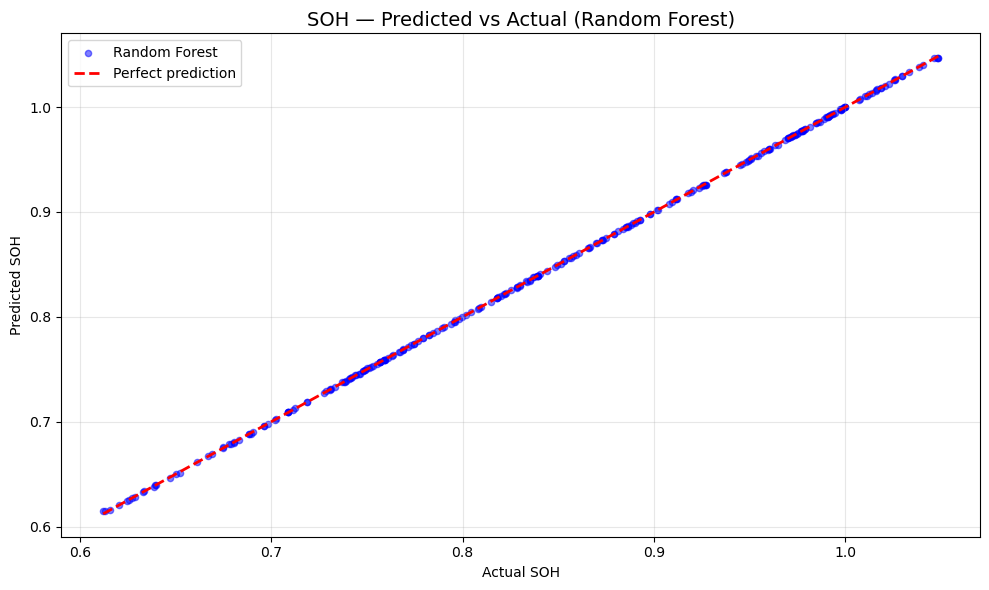

Chart 6 saved!


In [15]:
# SOH - Predicted vs Actual chart (best model)
plt.figure(figsize=(10, 6))

plt.scatter(y_soh_test, y_pred_rf_soh, 
            alpha=0.5, color='blue', s=20, label='Random Forest')
plt.plot([y_soh_test.min(), y_soh_test.max()],
         [y_soh_test.min(), y_soh_test.max()],
         'r--', linewidth=2, label='Perfect prediction')

plt.title('SOH — Predicted vs Actual (Random Forest)', fontsize=14)
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart6_soh_predicted_vs_actual.png', dpi=150)
plt.show()
print("Chart 6 saved!")

In [17]:
# RUL Model 1 - Linear Regression
lr_rul = LinearRegression()
lr_rul.fit(X_train_rul, y_rul_train)
y_pred_lr_rul = lr_rul.predict(X_test_rul)

# RUL Model 2 - Random Forest
rf_rul = RandomForestRegressor(n_estimators=100, random_state=42)
rf_rul.fit(X_train_rul, y_rul_train)
y_pred_rf_rul = rf_rul.predict(X_test_rul)

# RUL Model 3 - XGBoost
xgb_rul = XGBRegressor(n_estimators=100, random_state=42)
xgb_rul.fit(X_train_rul, y_rul_train)
y_pred_xgb_rul = xgb_rul.predict(X_test_rul)

# RUL comparison table
results_rul = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_rul_test, y_pred_lr_rul),
        mean_absolute_error(y_rul_test, y_pred_rf_rul),
        mean_absolute_error(y_rul_test, y_pred_xgb_rul)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_rul_test, y_pred_lr_rul)),
        np.sqrt(mean_squared_error(y_rul_test, y_pred_rf_rul)),
        np.sqrt(mean_squared_error(y_rul_test, y_pred_xgb_rul))
    ],
    'R2': [
        r2_score(y_rul_test, y_pred_lr_rul),
        r2_score(y_rul_test, y_pred_rf_rul),
        r2_score(y_rul_test, y_pred_xgb_rul)
    ]
})

print("=== RUL MODEL COMPARISON ===")
print(results_rul.round(4))

=== RUL MODEL COMPARISON ===
               Model      MAE     RMSE      R2
0  Linear Regression  25.3157  32.4662  0.4101
1      Random Forest   2.4659   4.5095  0.9886
2            XGBoost   2.7925   5.7499  0.9815


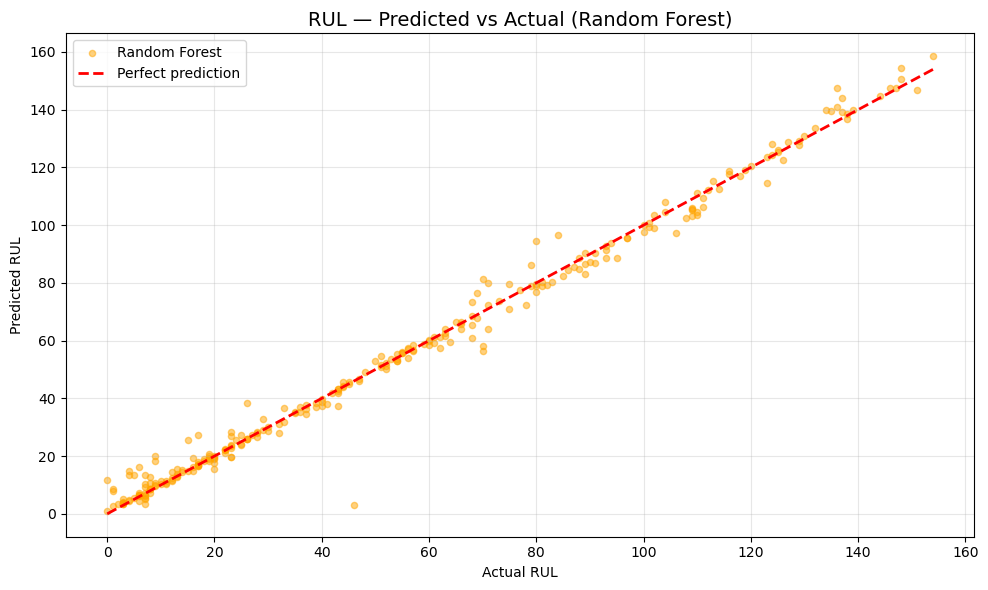

Chart 7 saved!


In [19]:
# RUL - Predicted vs Actual chart
plt.figure(figsize=(10, 6))

plt.scatter(y_rul_test, y_pred_rf_rul,
            alpha=0.5, color='orange', s=20, label='Random Forest')
plt.plot([y_rul_test.min(), y_rul_test.max()],
         [y_rul_test.min(), y_rul_test.max()],
         'r--', linewidth=2, label='Perfect prediction')

plt.title('RUL — Predicted vs Actual (Random Forest)', fontsize=14)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart7_rul_predicted_vs_actual.png', dpi=150)
plt.show()
print("Chart 7 saved!")

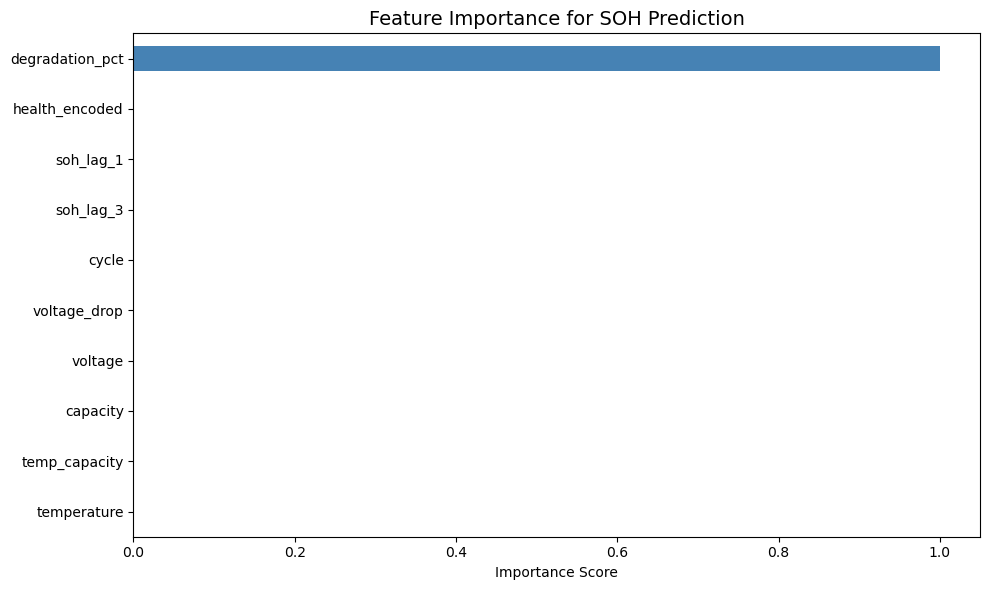

Chart 8 saved!


In [21]:
# Feature importance from Random Forest
plt.figure(figsize=(10, 6))

feature_importance = pd.Series(
    rf_soh.feature_importances_, 
    index=features
).sort_values(ascending=True)

feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance for SOH Prediction', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart8_feature_importance.png', dpi=150)
plt.show()
print("Chart 8 saved!")

In [23]:
import joblib

# Save best models
joblib.dump(rf_soh, 'soh_model.pkl')
joblib.dump(rf_rul, 'rul_model.pkl')

print("Models saved successfully!")
print("soh_model.pkl — predicts State of Health")
print("rul_model.pkl — predicts Remaining Useful Life")

Models saved successfully!
soh_model.pkl — predicts State of Health
rul_model.pkl — predicts Remaining Useful Life
